# Cytokines EDA

In [48]:
from itertools import combinations
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

In [13]:
# Load data
df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260731.csv")
df.head()

,sample_names,sample_id,cohort,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,...,globalhealthstatusql2,qlq30score,hn35,pathologicstage,lvi,pni,survival_status,sx_to_lastfu,survival_2yrs,ss
0,FF301C,FF301C,LLU,29.45,25.24,90.00,6.40,3.95,4.21,3.54,...,75.00,81.62,30.56,stage_I,no,no,alive,1839,alive,1
1,FF302C,FF302C,LLU,71.50,9.93,46.35,0.00,0.00,2.33,3.42,...,16.67,46.11,47.78,stage_IVA,no,yes,alive,1721,alive,4
2,FF303C,FF303C,LLU,54.54,18.38,54.01,46.49,18.90,1.37,4.15,...,50.00,57.56,45.68,stage_IVA,yes,no,death,48,death,4
3,FF304C,FF304C,LLU,132.67,27.47,81.82,6.89,3.95,4.56,9.69,...,0.00,19.23,94.44,stage_IVA,no,yes,death,131,death,3
4,FF305C,FF305C,LLU,28.01,13.63,66.20,5.44,0.92,3.04,2.42,...,75.00,76.67,17.44,stage_II,no,no,alive,1679,alive,1


In [3]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "ages", "sex", "race", "tobaccouse", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

In [14]:
# Subset cytokines and cohort columns for analysis
cytokines_df = df.loc[:, cytokines + ["cohort", "ss"]].drop(columns=["tgfalpha", "hbegf"])

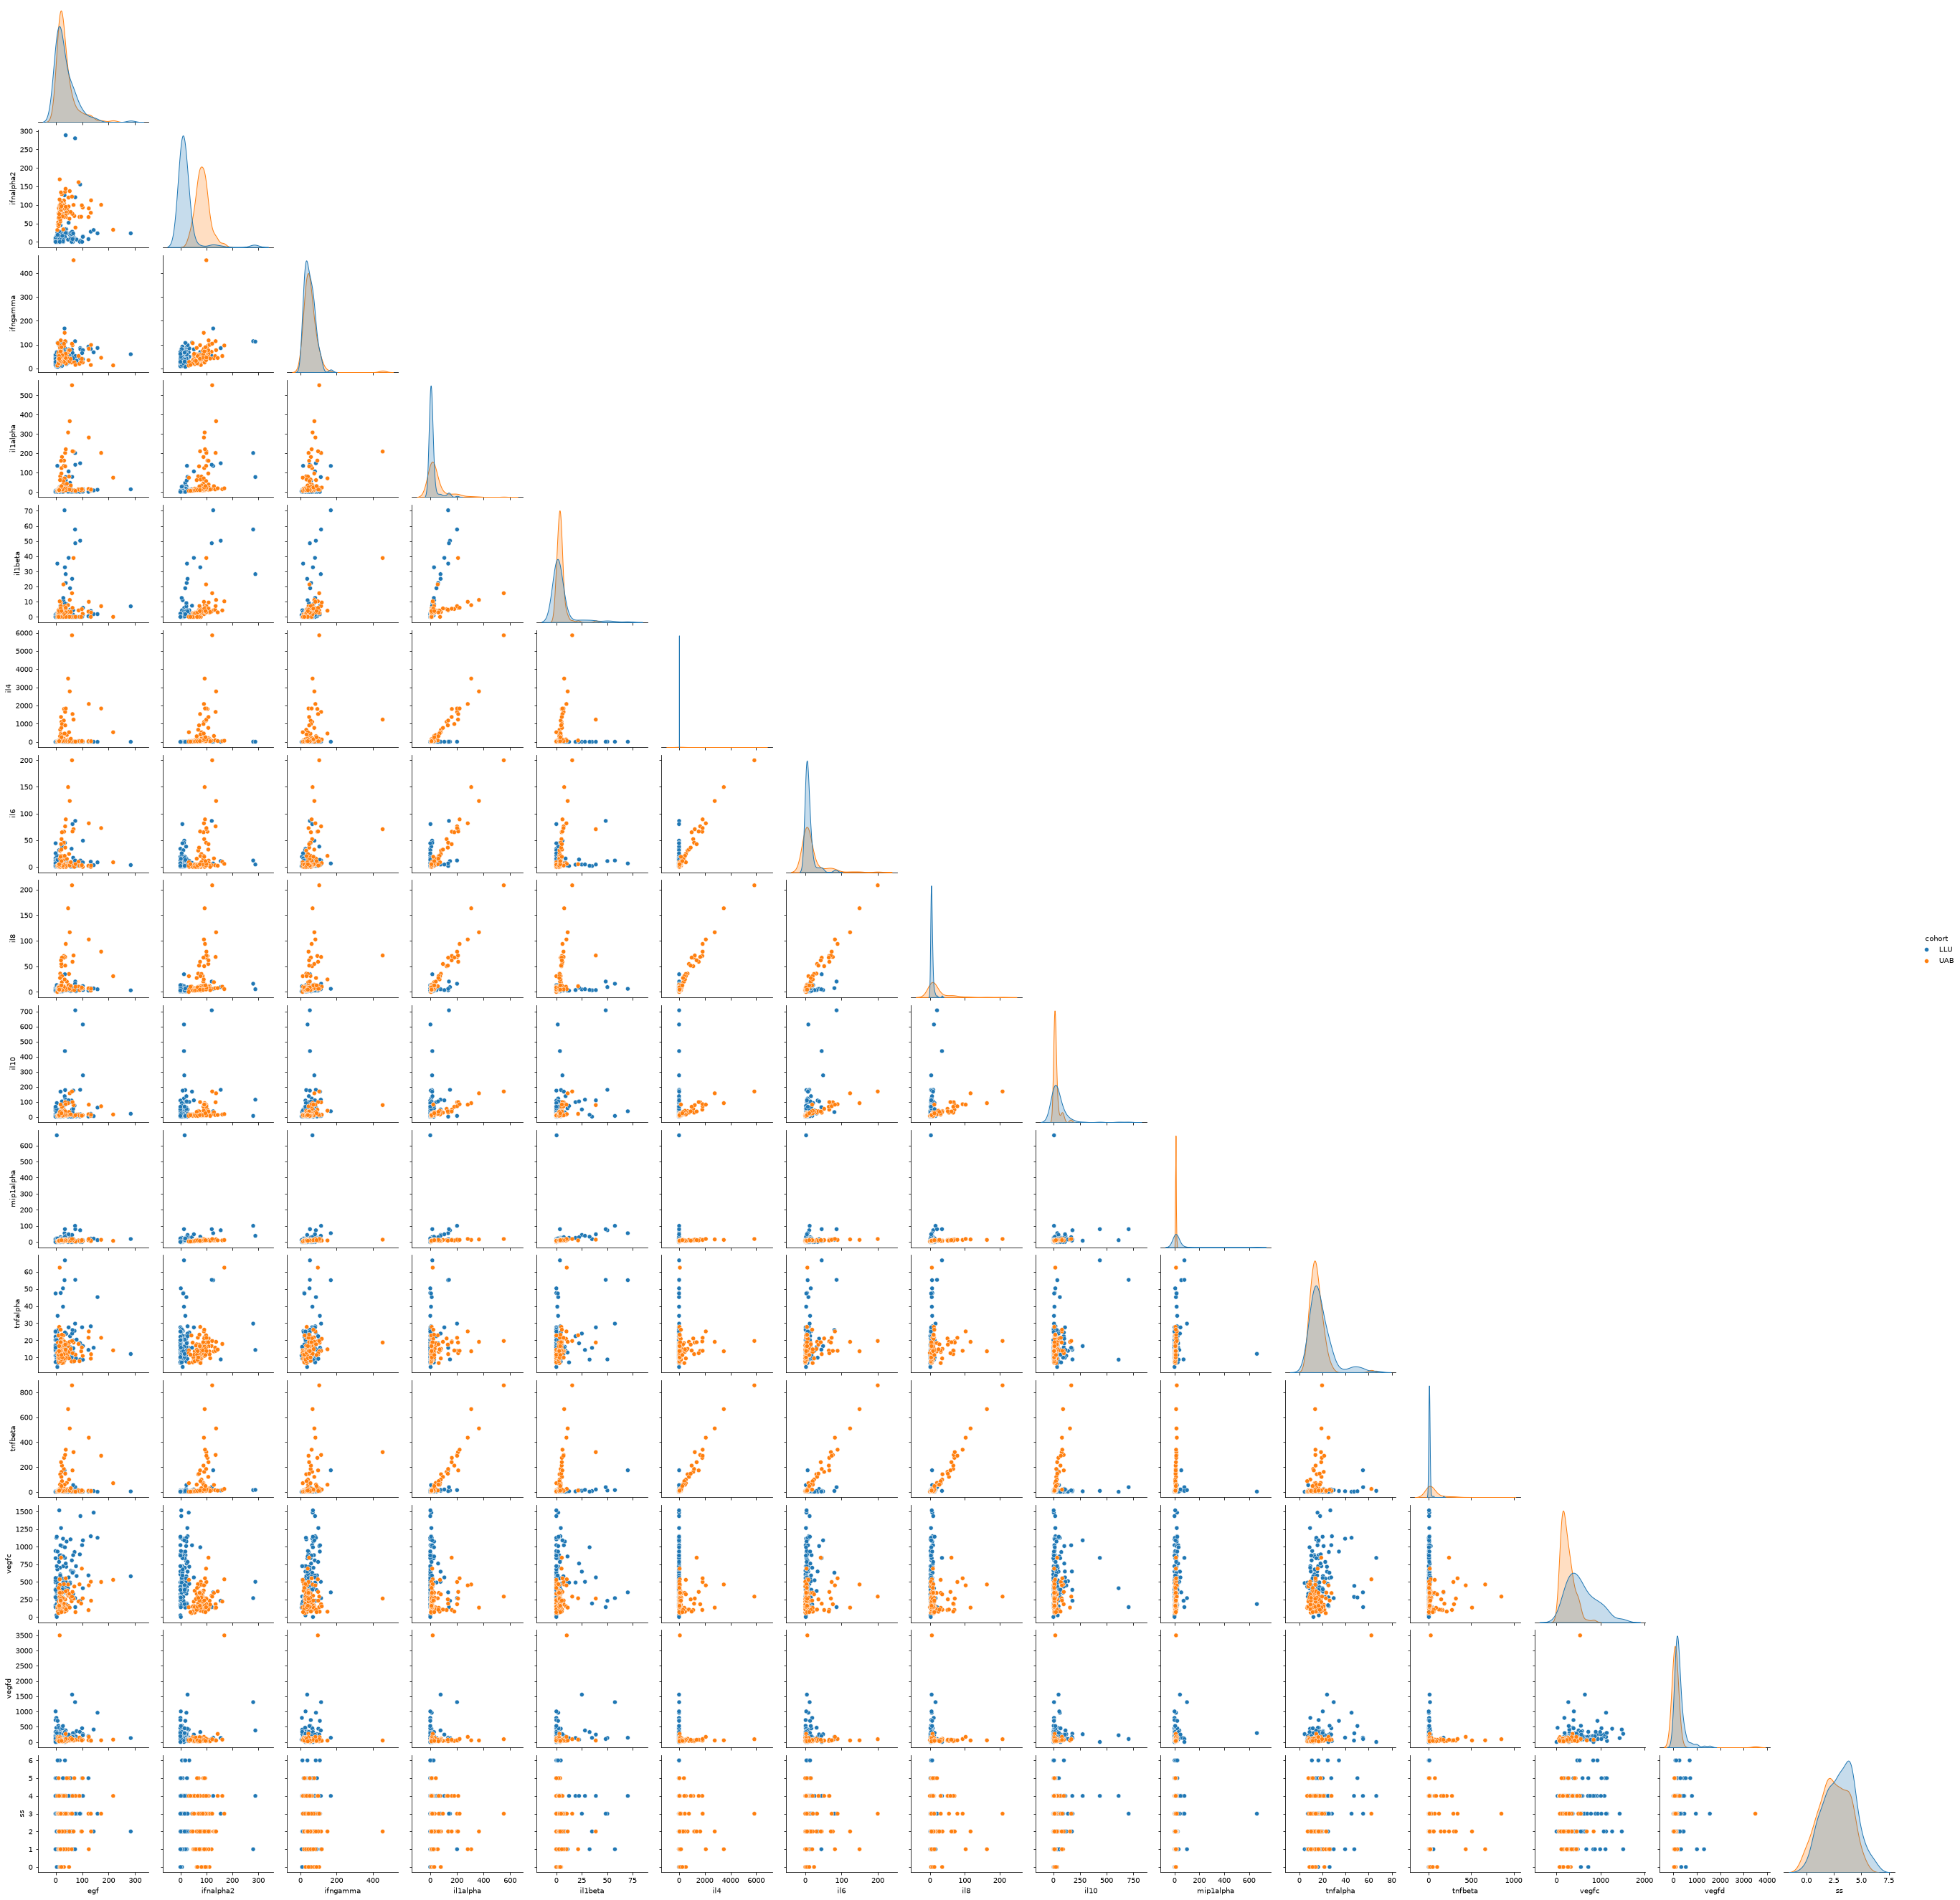

In [15]:
# Pairwise relationships of cytokines by cohort before z-score normalization
sns.pairplot(cytokines_df, hue="cohort", corner=True)
plt.show()

In [16]:
# Z-normalization of the cytokine values based on cohort (due to two different platforms on the two cohorts)
def pairwise_ttests(df, group_col="cohort", alpha=0.05, correction="fdr_bh"):
    cytokine_cols = df.columns.drop(group_col)
    groups = df[group_col].unique()
    results = []

    for cytokine in cytokine_cols:
        for g1, g2 in combinations(groups, 2):
            x = df.loc[df[group_col] == g1, cytokine].dropna()
            y = df.loc[df[group_col] == g2, cytokine].dropna()

            # Welch's t-test (doesn't assume equal variance)
            t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)

            results.append({
                "cytokine": cytokine,
                "group1": g1,
                "group2": g2,
                "n1": len(x),
                "n2": len(y),
                "mean1": x.mean(),
                "mean2": y.mean(),
                "t_stat": t_stat,
                "p_val": p_val
            })

    results_df = pd.DataFrame(results)

    # Multiple comparison correction across all tests
    reject, p_adj, _, _ = multipletests(results_df["p_val"], alpha=alpha, method=correction)
    results_df["p_adj"] = p_adj
    results_df["significant"] = reject

    return results_df.sort_values("p_adj")

ttest_results_before_standardization = pairwise_ttests(cytokines_df, group_col="cohort")
ttest_results_before_standardization

,cytokine,group1,group2,n1,n2,mean1,mean2,t_stat,p_val,p_adj,significant
1,ifnalpha2,LLU,UAB,112,100,20.073393,83.8346,-13.258074,1.063046e-28,1.594569e-27,True
12,vegfc,LLU,UAB,112,100,565.782411,239.9467,9.385477,7.100584e-17,5.325438e-16,True
7,il8,LLU,UAB,112,100,4.901875,21.4862,-4.860657,4.264537e-06,2.132268e-05,True
5,il4,LLU,UAB,112,100,2.051875,391.1172,-4.657265,9.979270e-06,3.742226e-05,True
11,tnfbeta,LLU,UAB,112,100,7.262768,68.0095,-4.317958,3.664977e-05,1.099493e-04,True
3,il1alpha,LLU,UAB,112,100,14.490357,51.4201,-3.934820,1.369857e-04,3.424644e-04,True
13,vegfd,LLU,UAB,112,100,242.839107,102.3263,3.407729,8.142983e-04,1.744925e-03,True
10,tnfalpha,LLU,UAB,112,100,18.695536,14.8800,3.128894,2.035176e-03,3.815954e-03,True
8,il10,LLU,UAB,112,100,53.279911,25.0158,2.801029,5.864884e-03,9.774807e-03,True
14,ss,LLU,UAB,112,100,3.035714,2.5300,2.733538,6.804761e-03,1.020714e-02,True


In [17]:
# Z-normalization of the cytokine values based on cohort (due to two different platforms on the two cohorts)
cytokine_features = cytokines_df.columns.drop("cohort")

sc = StandardScaler()

cytokines_standardization_df = cytokines_df.copy()
cytokines_standardization_df[cytokine_features] = (
    cytokines_standardization_df.groupby("cohort")[cytokine_features]
    .transform(lambda x: sc.fit_transform(x.to_numpy().reshape(-1, 1)).ravel())
)

cytokines_standardization_df

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,cohort,ss
0,-0.148154,0.121418,1.409269,-0.236668,-0.106581,1.045099,-0.432814,-0.182359,-0.485307,0.100156,0.004131,0.184295,-0.556037,0.084989,LLU,-1.501561
1,0.869503,-0.238375,-0.121928,-0.423888,-0.426731,0.134685,-0.441613,-0.089010,0.215519,-0.262735,0.635905,-0.203060,1.079924,-0.022325,LLU,0.711266
2,0.459052,-0.039796,0.146777,0.936090,1.105124,-0.330206,-0.388083,-0.318792,0.442933,0.086290,0.343245,-0.140230,-0.228049,-0.472525,LLU,0.711266
3,2.349885,0.173824,1.122323,-0.222334,-0.106581,1.214591,0.018162,0.571611,-0.321014,0.011758,0.881182,0.118583,1.757109,-0.877267,LLU,-0.026343
4,-0.183004,-0.151423,0.574390,-0.264751,-0.352165,0.478512,-0.514943,0.128803,-0.419334,-0.038351,1.943120,-0.076247,1.652214,-0.421727,LLU,-1.501561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,0.668459,1.483059,1.016899,5.716271,2.450417,6.584278,5.607206,5.541594,4.921763,3.000118,0.721482,5.664938,0.342350,-0.031358,UAB,0.355378
208,-0.507584,0.308943,0.342188,-0.328103,0.302498,-0.294040,0.058200,-0.261465,1.954145,0.676460,1.710124,-0.352185,-0.039353,-0.107783,UAB,-1.156869
209,-0.667978,-0.668846,-0.073727,-0.478858,-0.230269,-0.436123,-0.453761,-0.373570,-0.602483,0.245331,-0.167541,-0.437138,-0.652859,-0.137579,UAB,1.111501
210,-0.649670,-0.339323,-0.300095,-0.484564,-0.036536,-0.424369,-0.369048,-0.503766,-0.430010,-0.651797,0.267160,-0.409660,-0.555618,-0.235499,UAB,-0.400745


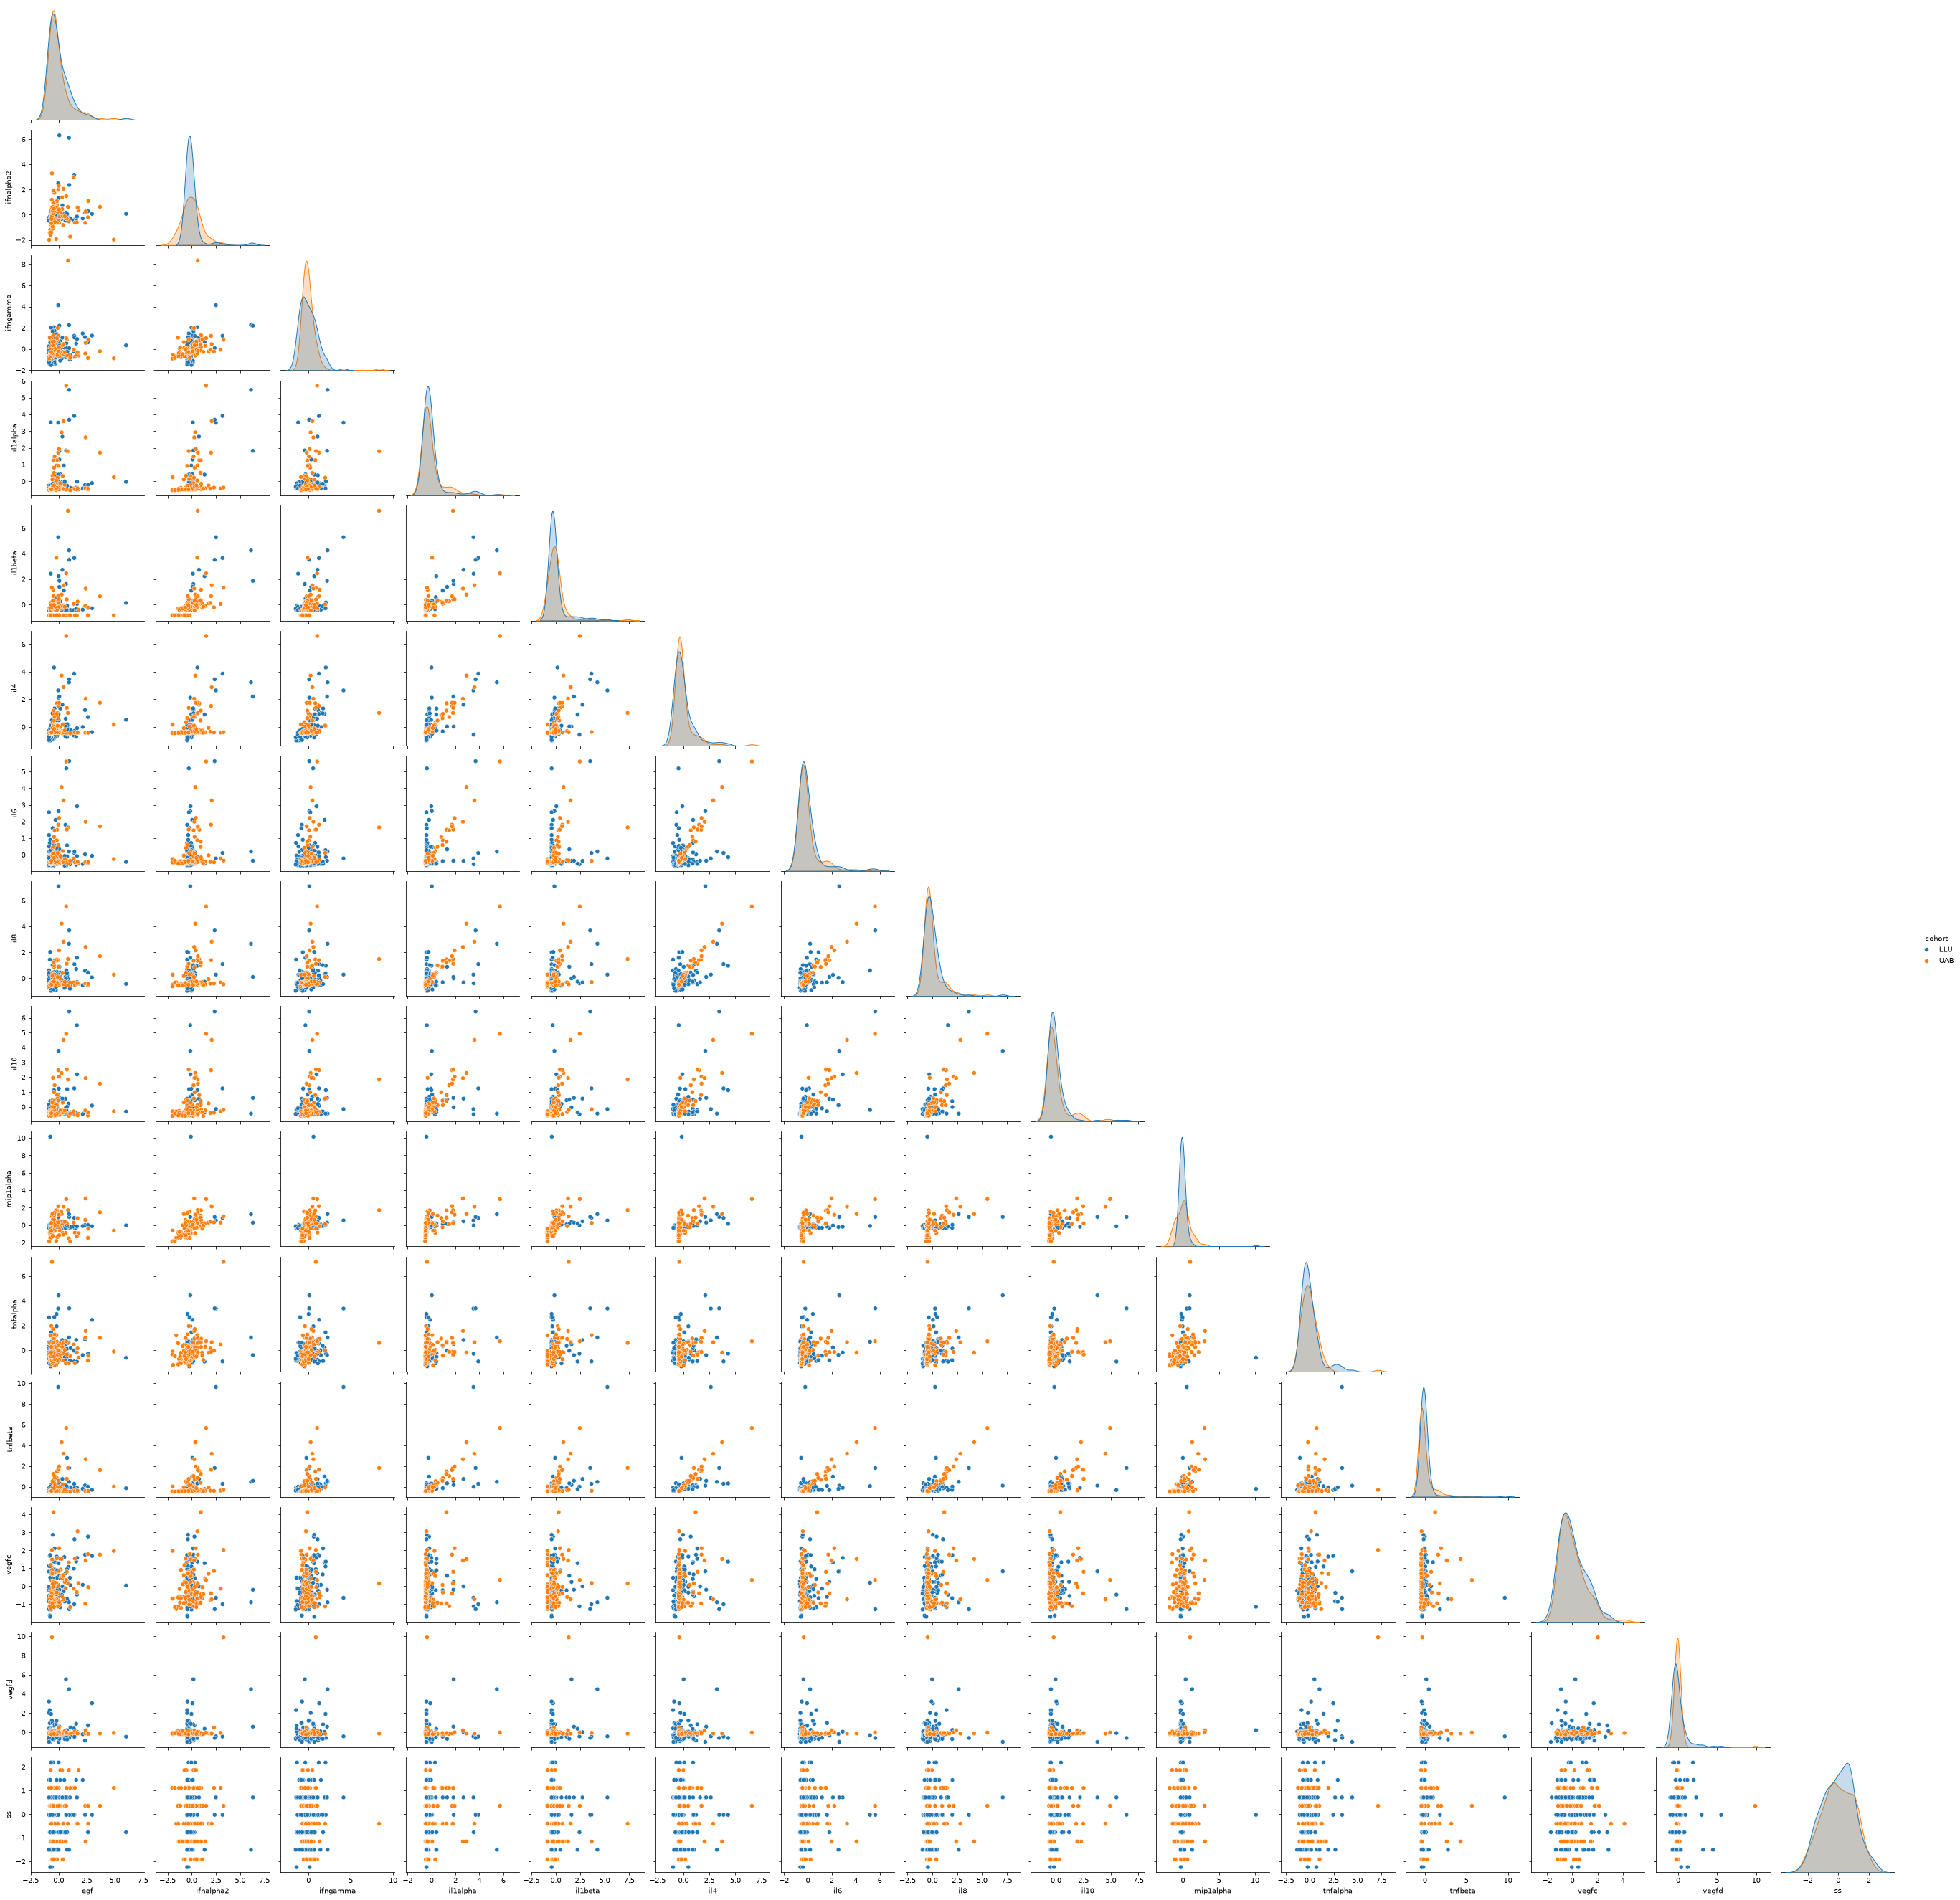

In [18]:
sns.pairplot(cytokines_standardization_df, hue="cohort", corner=True)
plt.show()

In [19]:
pairwise_ttests_after_standardization = pairwise_ttests(cytokines_standardization_df, group_col="cohort")

pairwise_ttests_after_standardization

,cytokine,group1,group2,n1,n2,mean1,mean2,t_stat,p_val,p_adj,significant
0,egf,LLU,UAB,112,100,6.344132e-17,2.203793e-16,-1.135265e-15,1.0,1.0,False
1,ifnalpha2,LLU,UAB,112,100,3.172066e-17,-3.019807e-16,2.413945e-15,1.0,1.0,False
2,ifngamma,LLU,UAB,112,100,-3.172066e-17,1.221245e-16,-1.112893e-15,1.0,1.0,False
3,il1alpha,LLU,UAB,112,100,-5.551115e-17,-6.800116e-17,9.035084e-17,1.0,1.0,False
4,il1beta,LLU,UAB,112,100,-5.551115e-17,-6.654399e-17,7.980991e-17,1.0,1.0,False
5,il4,LLU,UAB,112,100,4.758099e-17,-6.245005e-17,7.959479e-16,1.0,1.0,False
6,il6,LLU,UAB,112,100,-2.379049e-17,-1.360023e-17,-7.371481e-17,1.0,1.0,False
7,il8,LLU,UAB,112,100,1.229175e-16,-1.221245e-17,9.775100e-16,1.0,1.0,False
8,il10,LLU,UAB,112,100,-7.533656e-17,3.132911e-17,-7.716033e-16,1.0,1.0,False
9,mip1alpha,LLU,UAB,112,100,7.930164e-18,7.882583e-17,-5.128486e-16,1.0,1.0,False
